In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
from copy import deepcopy

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
x = torch.from_numpy(np.load("/content/drive/MyDrive/commentData_sbert_embeddings_TitleComment.npy"))
y = torch.from_numpy(np.load("/content/drive/MyDrive/commentData_labels_TitleComment.npy")).unsqueeze(1).float()

<h1>데이터 전처리</h1>

In [9]:
from sklearn.model_selection import train_test_split
import torch

x_np = x.numpy()
y_np = y.numpy().reshape(-1)

print(np.shape(x_np), np.shape(y_np))
x_train_np, x_temp_np, y_train_np, y_temp_np = train_test_split(
    x_np, y_np, test_size=0.15, stratify=y_np, random_state=42
)

x_valid_np, x_test_np, y_valid_np, y_test_np = train_test_split(
    x_temp_np, y_temp_np, test_size=0.5, stratify=y_temp_np, random_state=42
)

x_train = torch.tensor(x_train_np, dtype=torch.float32)
x_valid = torch.tensor(x_valid_np, dtype=torch.float32)
x_test  = torch.tensor(x_test_np, dtype=torch.float32)

y_train = torch.tensor(y_train_np, dtype=torch.float32).view(-1,1)
y_valid = torch.tensor(y_valid_np, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test_np, dtype=torch.float32).view(-1,1)

# Train / Valid / Test = 0.85 0.075 0.075
print("Train / Valid / Test = ", x_train.size(0), x_valid.size(0), x_test.size(0))

(3924, 768) (3924,)
Train / Valid / Test =  3335 294 295


<h1>모델</h1>

In [12]:
class MyModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.layers(x)

model = MyModel(input_dim=x_train.size(1))

<h1>Loss / Optimizer </h1>

In [14]:
crit = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

<h1> Train </h1>

In [15]:
n_epochs = 200
batch_size = 128
early_stop = 10
print_interval = 10

lowest_loss = np.inf
lowest_epoch = 0
best_model = None

train_history, valid_history = [], []

for epoch in range(n_epochs):
    model.train()
    indices = torch.randperm(x_train.size(0))
    x_train_shuffled = x_train[indices]
    y_train_shuffled = y_train[indices]

    train_loss = 0
    for i in range(0, x_train.size(0), batch_size):
        x_batch = x_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        optimizer.zero_grad()
        y_hat = model(x_batch)
        loss = crit(y_hat, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= x_train.size(0)

    # ---- Validation ----
    model.eval()
    valid_loss = 0
    with torch.no_grad():
        for i in range(0, x_valid.size(0), batch_size):
            x_batch = x_valid[i:i+batch_size]
            y_batch = y_valid[i:i+batch_size]
            y_hat = model(x_batch)
            loss = crit(y_hat, y_batch)
            valid_loss += loss.item() * x_batch.size(0)
    valid_loss /= x_valid.size(0)

    train_history.append(train_loss)
    valid_history.append(valid_loss)

    # ---- Logging ----
    if (epoch+1) % print_interval == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4e} valid_loss={valid_loss:.4e} lowest={lowest_loss:.4e}")

    # ---- Early stopping ----
    if valid_loss < lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = epoch
        best_model = deepcopy(model.state_dict())
    elif epoch - lowest_epoch >= early_stop:
        print(f"No improvement for {early_stop} epochs. Stopping at epoch {epoch+1}")
        break

Epoch 10: train_loss=2.5279e-02 valid_loss=3.5860e-02 lowest=3.2689e-02
Epoch 20: train_loss=9.7654e-03 valid_loss=3.1074e-02 lowest=2.4862e-02
No improvement for 10 epochs. Stopping at epoch 25


<h1> 성능 </h1>

Best validation loss: 2.4862e-02 at epoch 15


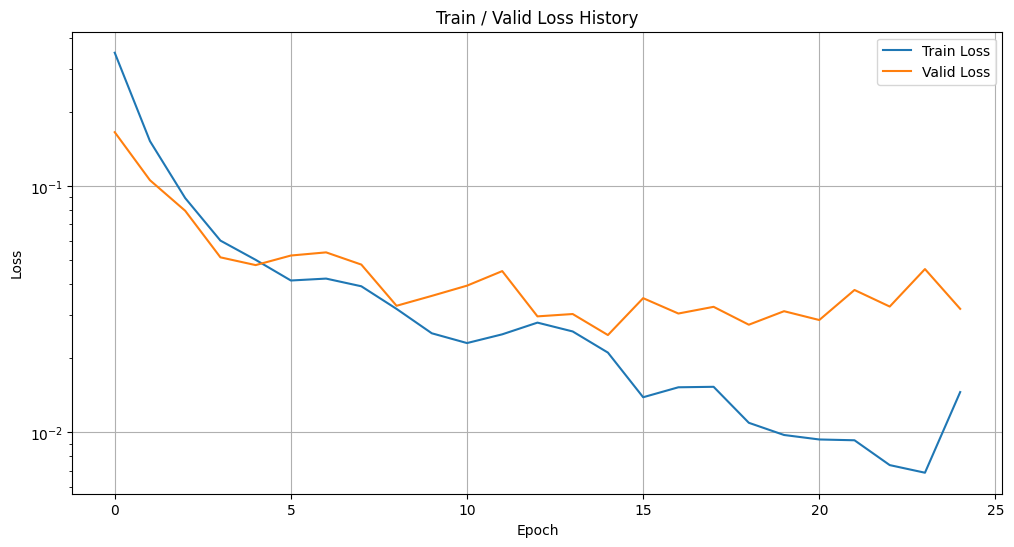


Optimal threshold on valid set: 0.67 with F1=0.9966

=== Test Performance (optimal threshold) ===
Accuracy : 0.9864
Precision: 0.9931
Recall   : 0.9795
F1-score : 0.9862
ROC AUC  : 0.9994


In [16]:
model.load_state_dict(best_model)
print(f"Best validation loss: {lowest_loss:.4e} at epoch {lowest_epoch+1}")

plt.figure(figsize=(12,6))
plt.plot(train_history, label='Train Loss')
plt.plot(valid_history, label='Valid Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train / Valid Loss History')
plt.grid(True)
plt.legend()
plt.show()

model.eval()
with torch.no_grad():
    y_hat_test = model(x_test)
    y_prob_test = torch.sigmoid(y_hat_test).numpy()
    y_true_test = y_test.numpy()

    y_hat_val = model(x_valid)
    y_prob_val = torch.sigmoid(y_hat_val).numpy()
    y_true_val = y_valid.numpy()

# Optimal threshold (F1 기준)
thresholds = np.linspace(0.01,0.99,99)
best_f1 = 0
best_thresh = 0.5
for t in thresholds:
    y_val_pred = (y_prob_val > t).astype(int)
    f1 = f1_score(y_true_val, y_val_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t
print(f"\nOptimal threshold on valid set: {best_thresh:.2f} with F1={best_f1:.4f}")

# Test performance at optimal threshold
y_pred_opt = (y_prob_test > best_thresh).astype(int)
print("\n=== Test Performance (optimal threshold) ===")
print(f"Accuracy : {accuracy_score(y_true_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_true_test, y_pred_opt):.4f}")
print(f"Recall   : {recall_score(y_true_test, y_pred_opt):.4f}")
print(f"F1-score : {f1_score(y_true_test, y_pred_opt):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_true_test, y_prob_test):.4f}")

<h1> 모델 저장 </h1>

In [17]:
torch.save(model.state_dict(), 'comment_classifier.pth')
print("\n모델 저장 완료: comment_classifier.pth")


모델 저장 완료: comment_classifier.pth


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load('/content/comment_classifier.pth', map_location=device))
# model.load_state_dict(torch.load('/content/drive/MyDrive/comment_classifier.pth', map_location=device))
model.eval()
model.to(device)

MyModel(
  (layers): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

<h1> 모델 테스트 </h1>

In [19]:
from sentence_transformers import SentenceTransformer
sbert_model = SentenceTransformer('snunlp/KR-SBERT-V40K-klueNLI-augSTS')  # 예시

In [20]:
def predict_comment(text, threshold=0.5):
    # 1. 임베딩
    embedding = sbert_model.encode(text, convert_to_tensor=True).cpu()
    x = embedding.unsqueeze(0)

    # 2. 예측
    model.eval()
    with torch.no_grad():
        logit = model(x)
        prob = torch.sigmoid(logit).item()  # sigmoid 적용

    # 3. 레이블 결정
    label = 1 if prob >= threshold else 0
    label_str = "봇" if label == 1 else "인간"

    return {
        "text": text,
        "probability": round(prob, 4),
        "prediction": label_str,
        "is_malicious": label
    }


In [21]:
if __name__ == "__main__":
    test_comments = [
        "특검에만 의존 말고 독자 조사도 해야 공무원들이 사회적 책임을 명확히 이행하고 있는지 확인하는 것이 우리 모두의 권리이며 이는 국가의 신뢰와 직결되기 때문에 매우 중요합니다",
        "국짐은 정말....헌법 명시된 일자를 시간으로 바꿔 써결이 풀어줬고 즉시 항소포기를 눈감고 모른체 했던 내란세력이.....하늘을 손가리고 아웅해도 유분수지!! 개돼지 노인들과 개독교, 사이비 질질끌고 근근히 살아가는 국짐은 해체가 답이다!!",
        "종묘 앞 재개발은 단순한 부동산 이익을 넘어서 우리 민족의 정체성을 위협한다. 서울시가 재개발을 추진하면서 정당성보다는 정치적 이익을 먼저 생각한다면, 결국 우리 세대는 후세에 문화유산을 물려줄 수 없게 된다.",
        "軍, 남북군사회담 제안…'군사분계선 기준선 설정 논의' 찢재명 대통령 되니까 아예 북한에다가 남한 땅 주려고 난리네. 정은이가 시키드나!! ㅋㅋㅋㅋㅋ",
        "軍, 남북군사회담 제안…'군사분계선 기준선 설정 논의' 이재명 정부가 첫 남북 회담을 제안했다는 소식에 조금이나마 희망을 걸어봅니다. 북한이 긍정적으로 응답해 긴장을 완화하고 서로의 신뢰를 쌓을 수 있기를 바랍니다.",
        "1천차례 사고해역 갔지만…좌초 여객선 선장, 조타실 가지않아 박근혜때 처럼 리죄명 DOG BABY 구속해야제?거시기잖아/?",
        "한덕수 '尹 계엄 결정 돌리려 했으나 역부족'…1월 21일 선고(종합) 덕수는 감형없이 징역 10년 이상만 나와도 사실상 무기징역이나 마찬가지지. 어차피 살아서는 감옥 못 나온다. 기왕 이렇게 된 거 윤석열이랑 왕정복고 추진해 김건희 여왕 만들려고 했다고 다 불어라. 안 그러면 김건희 무속 동무인 네 마누라도 구속될 거다.",
    ]

    print("봇 탐지기 테스트\n" + "="*50)
    for comment in test_comments:
        result = predict_comment(comment, threshold=0.5)
        print(f"입력: {result['text']}")
        print(f"예측: {result['prediction']} (확률: {result['probability']})")
        print("-" * 50)

봇 탐지기 테스트
입력: 특검에만 의존 말고 독자 조사도 해야 공무원들이 사회적 책임을 명확히 이행하고 있는지 확인하는 것이 우리 모두의 권리이며 이는 국가의 신뢰와 직결되기 때문에 매우 중요합니다
예측: 봇 (확률: 1.0)
--------------------------------------------------
입력: 국짐은 정말....헌법 명시된 일자를 시간으로 바꿔 써결이 풀어줬고 즉시 항소포기를 눈감고 모른체 했던 내란세력이.....하늘을 손가리고 아웅해도 유분수지!! 개돼지 노인들과 개독교, 사이비 질질끌고 근근히 살아가는 국짐은 해체가 답이다!!
예측: 인간 (확률: 0.0002)
--------------------------------------------------
입력: 종묘 앞 재개발은 단순한 부동산 이익을 넘어서 우리 민족의 정체성을 위협한다. 서울시가 재개발을 추진하면서 정당성보다는 정치적 이익을 먼저 생각한다면, 결국 우리 세대는 후세에 문화유산을 물려줄 수 없게 된다.
예측: 봇 (확률: 0.9964)
--------------------------------------------------
입력: 軍, 남북군사회담 제안…'군사분계선 기준선 설정 논의' 찢재명 대통령 되니까 아예 북한에다가 남한 땅 주려고 난리네. 정은이가 시키드나!! ㅋㅋㅋㅋㅋ
예측: 인간 (확률: 0.0002)
--------------------------------------------------
입력: 軍, 남북군사회담 제안…'군사분계선 기준선 설정 논의' 이재명 정부가 첫 남북 회담을 제안했다는 소식에 조금이나마 희망을 걸어봅니다. 북한이 긍정적으로 응답해 긴장을 완화하고 서로의 신뢰를 쌓을 수 있기를 바랍니다.
예측: 봇 (확률: 0.9991)
--------------------------------------------------
입력: 1천차례 사고해역 갔지만…좌초 여객선 선장, 조타실 가지않아 박근혜때 처럼 리죄명 DOG BABY 구속해야제?거